# Introduction

Welcome to this lab!
At this lab, we will learn how to implement Graph Convolutional Networks (GCN) based on the paper [GCN](https://arxiv.org/pdf/1609.02907.pdf).

# Exercise

## Download data and install packages

In [1]:
from pathlib import Path
import importlib.util
import os
import shutil
import subprocess
import sys

if importlib.util.find_spec("gdown") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])

import gdown

work_dir = Path.cwd()
archive_path = work_dir / "lab2.rar"

# Download using gdown with correct syntax (newer versions don't use --id)
if not archive_path.exists():
    url = "https://drive.google.com/uc?id=1Z748ksOFWZ8WLsy0P8T7eYA6XLVLieX3"
    gdown.download(url, output=str(archive_path), quiet=False)

# Extract using Windows-compatible method
extractors = []
for name in ("unrar", "7z", "7zz", "7za", "tar"):
    path = shutil.which(name)
    if path:
        extractors.append((name, path))

for candidate in (
    Path("C:/Program Files/7-Zip/7z.exe"),
    Path("C:/Program Files (x86)/7-Zip/7z.exe"),
    Path("C:/Program Files/WinRAR/UnRAR.exe"),
    Path("C:/Program Files/WinRAR/WinRAR.exe"),
):
    if candidate.exists():
        extractors.append((candidate.stem.lower(), str(candidate)))

for root in (Path(os.environ.get("ProgramFiles", "")), Path(os.environ.get("ProgramFiles(x86)", ""))):
    if root.exists():
        try:
            found_7z = next(root.rglob("7z.exe"), None)
            if found_7z:
                extractors.append(("7z", str(found_7z)))
        except OSError:
            pass

last_error = None
for kind, exe in extractors:
    try:
        if kind.startswith("unrar") or kind == "winrar":
            cmd = [exe, "x", "-y", "-o+", str(archive_path), str(work_dir) + os.sep]
        elif kind == "tar":
            cmd = [exe, "-xf", str(archive_path), "-C", str(work_dir)]
        else:
            cmd = [exe, "x", "-y", f"-o{work_dir}", str(archive_path)]
        subprocess.check_call(cmd)
        break
    except Exception as exc:
        last_error = exc
else:
    raise RuntimeError(
        "Cannot extract lab2.rar. Install 7-Zip or WinRAR, then run this cell again."
    ) from last_error

print("Ready:", work_dir / "lab2_edgelist.txt", work_dir / "lab2_attributes.csv")

Ready: C:\Users\ADMIN\OneDrive\Máy tính\GR1-bai_tap_thay_linh\ML-exercises\Ex17\lab2_edgelist.txt C:\Users\ADMIN\OneDrive\Máy tính\GR1-bai_tap_thay_linh\ML-exercises\Ex17\lab2_attributes.csv


## Packages: Import neccesary packages

In [2]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd

## Utils: Processing data

In [3]:
def create_graphs_with_attributes(edgelist_filepath,attributes_filepath):
    graph=nx.read_edgelist(edgelist_filepath,nodetype=int)
    attributes=pd.read_csv(attributes_filepath,index_col=['node'])
    att_values = {a:{'role':b[0],'community':b[1]} for a,b in enumerate(attributes.values)}
    nx.set_node_attributes(graph,att_values)
    return graph


def create_train_test(graph):
    X_train,Y_train,X_test,Y_test=[],[],[],[]
    for node, data in graph.nodes(data=True):
        if data['role'] in ['Administrator','Instructor']:
            X_train.append(node)
            Y_train.append(data['role']=='Administrator')
        elif data['role'] =='Member':
            X_test.append(node)
            Y_test.append(data['community']=='Administrator')
    return np.asarray(X_train),np.asarray(Y_train),np.asarray(X_test),np.asarray(Y_test)



def create_features(graph): # create input features, concatenation of identity matrix and shortest paths to targets
    A = nx.to_numpy_array(graph)  # Changed from to_numpy_matrix to to_numpy_array for NetworkX 3.0+
    X_1 = torch.eye(A.shape[0]) # identity matrix
    X_2 = torch.zeros((A.shape[0], 2)) # shortest path to the targets as 2nd input feature
    node_distance_instructor = nx.shortest_path_length(graph, target=33)
    node_distance_administrator = nx.shortest_path_length(graph, target=0)

    for node in graph.nodes():
        X_2[node][0] = node_distance_administrator[node]
        X_2[node][1] = node_distance_instructor[node]

    return torch.cat((X_1,X_2),dim=1)

## TO DO: Implement Graph Convolutional Networks (GCN)

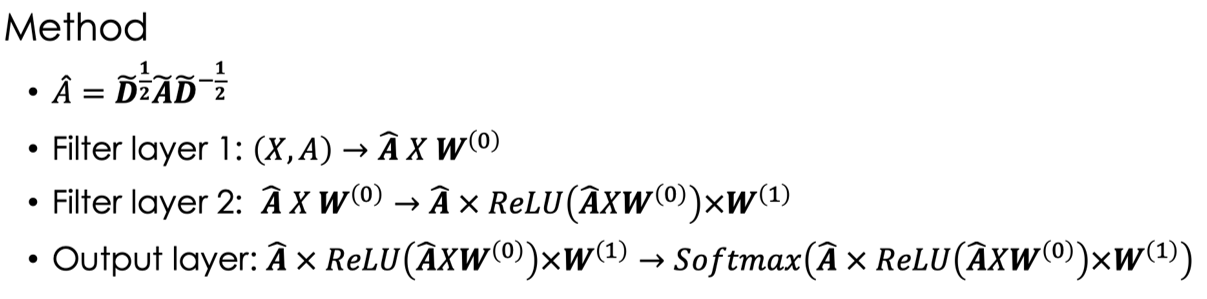

In [4]:
from torch.nn.parameter import Parameter

class GCN_layer(nn.Module):
    """
      Define filter layer 1/2 like in the above image
      Calculate A_hat first then,
      Input: adj_matrix with input features X
    """   

    def __init__(self, inputs_shape, outputs_shape):
        super(GCN_layer, self).__init__()

        self.W=Parameter(torch.rand(inputs_shape,outputs_shape),requires_grad=True)
        self.bias = Parameter(torch.rand(outputs_shape),requires_grad=True)

    
    def forward(self, adj_matrix, input_features):
        # TO DO: Calculate A_hat
        if not torch.is_tensor(adj_matrix):
            A = torch.tensor(adj_matrix, dtype=torch.float32)
        else:
            A = adj_matrix.float()

        if not torch.is_tensor(input_features):
            X = input_features.float()
        else:
            X = input_features.float()

        # Symmetric normalization: A_hat = D^{-1/2} (A + I) D^{-1/2}
        A_hat = A + torch.eye(A.size(0), dtype=A.dtype)
        deg = A_hat.sum(dim=1)
        deg_inv_sqrt = torch.pow(deg, -0.5)
        deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0
        D = torch.diag(deg_inv_sqrt)
        A_hat = torch.mm(torch.mm(D, A_hat), D)

        aggregate = torch.mm(A_hat, X)
        propagate = torch.mm(aggregate, self.W) + self.bias
        return propagate

In [5]:
class GCN(nn.Module):
    

    def __init__(self,inputs_shape,outputs_shape,n_classes,activation='Relu'):
        super(GCN, self).__init__()

        self.layer1=GCN_layer(inputs_shape,outputs_shape)
        self.layer2=GCN_layer(outputs_shape,n_classes)
        
        
        if activation =='Tanh':
            self.activation = nn.Tanh()
        elif activation=='Sigmoid':
            self.activation = nn.Sigmoid()
        elif activation=='Softmax':
            self.activation=nn.Softmax()
        elif activation=='Relu':
            self.activation=nn.ReLU()
    
        self.softmax=nn.Softmax(dim=1)  # Added dim=1 for softmax over class dimension
    
        
    def forward(self,adj_matrix,input_features):
        # TO DO: Define output for each layer. Please look at the method in the picture above
        h1 = self.activation(self.layer1(adj_matrix, input_features))
        h2 = self.layer2(adj_matrix, h1)
        x = self.softmax(h2)
        return x

In [6]:
import torch
from sklearn.metrics import classification_report
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import networkx as nx


graph=create_graphs_with_attributes('lab2_edgelist.txt','lab2_attributes.csv')
A = np.array(nx.to_numpy_array(graph)) # Changed from to_numpy_matrix to to_numpy_array for NetworkX 3.0+

class Trainer():
    def __init__(self,model,optimizer,loss_function,epochs):
        
        self.model=model
        self.optimizer=optimizer
        self.loss_function=loss_function
        self.epochs=epochs
        
    def train(self,X_train,Y_train):

        y_train=torch.from_numpy(Y_train.astype(int)).type(torch.LongTensor)
        tot_loss=0.0
        all_preds=[]

        for t in range(self.epochs):
            epoch_loss = 0.0

            #model.train()
            y_pred=self.model(A, create_features(graph))
            all_preds.append(y_pred)
            loss = self.loss_function(y_pred[X_train], y_train)
            self.optimizer.zero_grad()
            epoch_loss+=loss
            tot_loss+=loss
            loss.backward()
            self.optimizer.step()

            print(str(t),'epoch_loss:'+str(epoch_loss),'total loss:'+str(tot_loss))

        self.all_preds=all_preds
    
    def test(self,X_test,Y_test):

        self.model.eval()
        y_test=torch.from_numpy(Y_test.astype(int)).type(torch.LongTensor)
        y_pred=self.all_preds[-1]  # preds of last epoch
        loss_test = self.loss_function(y_pred[X_test],y_test)
        print('validation loss is equal to: '+str(loss_test))
    
    def visualize_classification(self,graph,Y_test,classification):
        last_epoch = self.all_preds[self.epochs-1].detach().numpy() # get outputs of last epoch
        predicted_class = np.argmax(last_epoch, axis=-1) # take the unit with the higher probability
        color = np.where(predicted_class==0, 'c', 'r')
        pos = nx.kamada_kawai_layout(graph)
        nx.draw_networkx(graph, pos, node_color=color, with_labels=True, node_size=300)
        if classification==True:
            print(classification_report(predicted_class[1:-1],Y_test))

## Run GCN

0 epoch_loss:tensor(0.8521, grad_fn=<AddBackward0>) total loss:tensor(0.8521, grad_fn=<AddBackward0>)
1 epoch_loss:tensor(0.8399, grad_fn=<AddBackward0>) total loss:tensor(1.6919, grad_fn=<AddBackward0>)
2 epoch_loss:tensor(0.8199, grad_fn=<AddBackward0>) total loss:tensor(2.5118, grad_fn=<AddBackward0>)
3 epoch_loss:tensor(0.7897, grad_fn=<AddBackward0>) total loss:tensor(3.3015, grad_fn=<AddBackward0>)
4 epoch_loss:tensor(0.7498, grad_fn=<AddBackward0>) total loss:tensor(4.0513, grad_fn=<AddBackward0>)
5 epoch_loss:tensor(0.7046, grad_fn=<AddBackward0>) total loss:tensor(4.7559, grad_fn=<AddBackward0>)
6 epoch_loss:tensor(0.6633, grad_fn=<AddBackward0>) total loss:tensor(5.4192, grad_fn=<AddBackward0>)
7 epoch_loss:tensor(0.6348, grad_fn=<AddBackward0>) total loss:tensor(6.0539, grad_fn=<AddBackward0>)
8 epoch_loss:tensor(0.6216, grad_fn=<AddBackward0>) total loss:tensor(6.6755, grad_fn=<AddBackward0>)
9 epoch_loss:tensor(0.6194, grad_fn=<AddBackward0>) total loss:tensor(7.2950, grad

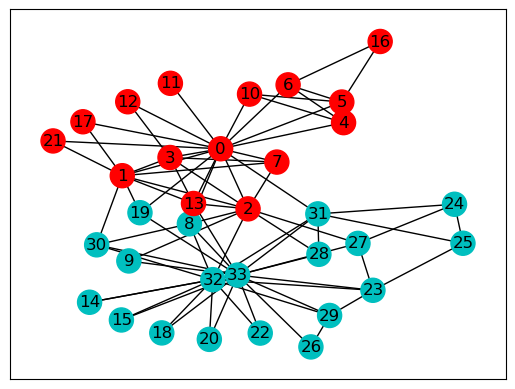

In [8]:
graph=create_graphs_with_attributes('lab2_edgelist.txt','lab2_attributes.csv')
A = nx.to_numpy_array(graph) # adjadjency matrix
X_train,Y_train,X_test,Y_test= create_train_test(graph)

model=GCN(inputs_shape=create_features(graph).shape[1],outputs_shape=4,n_classes=2,activation='Relu')
trainer = Trainer(
    model,
    optimizer = optim.Adam(model.parameters(), lr=0.01),
    loss_function=F.cross_entropy,
    epochs=250
)

trainer.train(X_train,Y_train)
trainer.test(X_test,Y_test)
trainer.visualize_classification(graph,Y_test,classification=True)